# Μέρος 1: Ανίχνευση Ακμών σε Γκρίζες Εικόνες

## 1.1 Δημιουργία Εικόνων Εισόδου

In [16]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

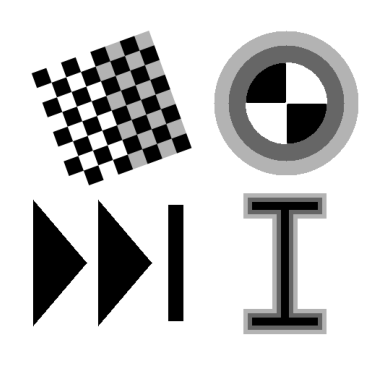

In [17]:
# Load and display first image
image0 = cv2.imread('edgetest_24.png')

# Convert the image from BGR to GRAY
image0 = cv2.cvtColor(image0, cv2.COLOR_BGR2GRAY)

# Display the image using Matplotlib
plt.imshow(image0, cmap='gray')
plt.axis('off')
plt.show()

In [18]:
# Create helper function

def PSNRnoise(image, psnr):
    # Gets image and PSNR as input,
    # returns image with gaussian noise, so that it has the given PSNR

    # Add Gaussian noise and tweak standard deviation (binary search) until the PSNR has the right value
    mean = 0
    std_dev = 20
    min_std_dev = None
    max_std_dev = None
    psnr_value = None

    while psnr_value!=psnr:
        gaussian_noise = np.random.normal(mean, std_dev, image0.shape).astype('uint8')
        noisy_image = cv2.add(image, gaussian_noise)

        # Calculate PSNR
        psnr_value = 20 * np.log10((noisy_image.max() - noisy_image.min()) / std_dev)

        if psnr_value > psnr:
            if max_std_dev:
                temp = std_dev
                std_dev += (max_std_dev - std_dev)/2
                min_std_dev = temp
            else:
                min_std_dev = std_dev
                std_dev *= 2
        elif psnr_value < psnr:
            if min_std_dev:
                temp = std_dev
                std_dev -= (std_dev - min_std_dev)/2
                max_std_dev = temp
            else:
                max_std_dev = std_dev
                std_dev/=2

    return noisy_image, psnr_value, std_dev

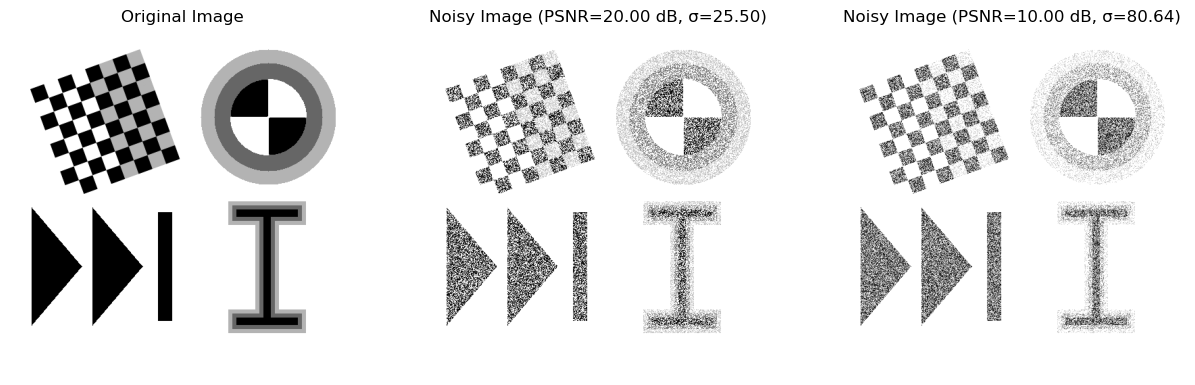

In [19]:
# Create noisy images
image0_20, psnr_20, std_dev_20 = PSNRnoise(image0, 20)
image0_10, psnr_10, std_dev_10 = PSNRnoise(image0, 10)

# Display original and noisy images
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(image0, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(image0_20, cmap='gray')
plt.title('Noisy Image (PSNR={:.2f} dB, σ={:.2f})'.format(psnr_20, std_dev_20))
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(image0_10, cmap='gray')
plt.title('Noisy Image (PSNR={:.2f} dB, σ={:.2f})'.format(psnr_10, std_dev_10))
plt.axis('off')

plt.subplots_adjust(right=1.3)
plt.show()

## 1.2 Υλοποίηση Αλγορίθμων Ανίχνευσης Ακμών

Implement Gaussian and Laplacian of Gaussian kernels

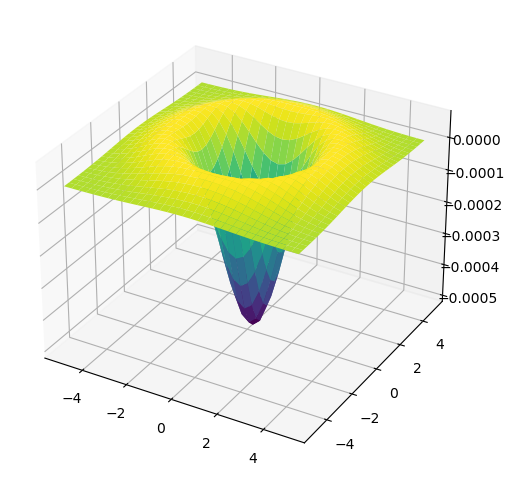

In [20]:
SIGMA = 5 # Standard deviation of the Gaussian kernel
KSIZE = int(np.ceil(3*SIGMA))*2 + 1 # Kernel size

def G():
    std_dev = SIGMA
    ksize = KSIZE
    kernel_1d = cv2.getGaussianKernel(ksize, std_dev)
    kernel_2d = kernel_1d @ kernel_1d.T
    return kernel_2d

def LoG():
    ksize = KSIZE
    sigma = SIGMA
    x, y = np.meshgrid(np.arange(-ksize//2, ksize//2 + 1), np.arange(-ksize//2, ksize//2 + 1))
    norm2 = x**2 + y**2
    kernel = -(1.0 / (np.pi * sigma**4)) * (1 - norm2 / (2.0 * sigma**2)) * np.exp(-norm2 / (2.0 * sigma**2))
    
    # Normalize Kernel
    kernel -= kernel.mean()

    return kernel

def plot3D(func):
    # Helper function, used to plot 3D numpy functions for debugging

    # Create a grid of (x, y) coordinates at which to evaluate the kernels
    x = np.linspace(-SIGMA, SIGMA, func.shape[0])
    y = np.linspace(-SIGMA, SIGMA, func.shape[1])
    X, Y = np.meshgrid(x, y)

    # Create a 3D plot
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, func, cmap='viridis')

    plt.show()

plot3D(LoG())

Apply L1 and L2 filters

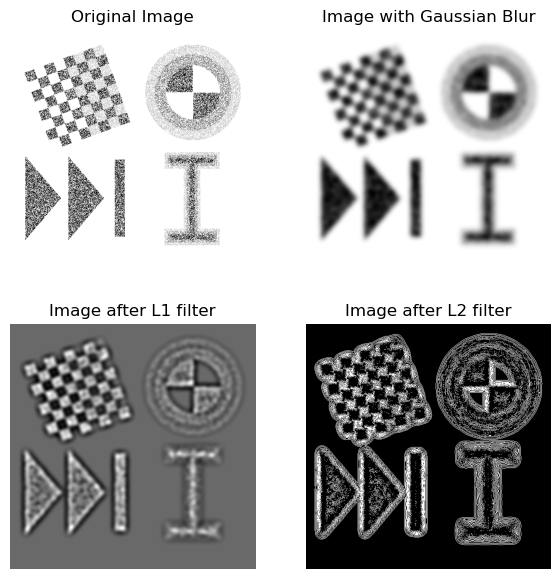

In [21]:
OG_IMAGE = image0_20 # You can change this to image_0 image0_20 or image0_10

# LoG filter
image0_L1 = cv2.filter2D(OG_IMAGE, cv2.CV_64F, LoG())

# Morphological filters
image0_blur = cv2.filter2D(OG_IMAGE, -1, G())
B = np.array([[0, 1, 0],
              [1, 1, 1],
              [0, 1, 0]], dtype=np.uint8)
image0_L2 = cv2.dilate(image0_blur, B) + cv2.erode(image0_blur, B) - 2*image0_blur

# Show results
plt.figure(figsize=(7, 7))

plt.subplot(2, 2, 1)
plt.title("Original Image")
plt.imshow(OG_IMAGE, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title("Image with Gaussian Blur")
plt.imshow(image0_blur, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title("Image after L1 filter")
plt.imshow(image0_L1, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title("Image after L2 filter")
plt.imshow(image0_L2, cmap='gray')
plt.axis('off')

plt.show()

Approach zero-crossings

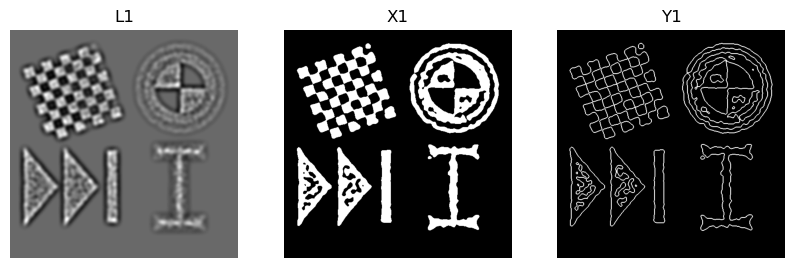

In [22]:
# Binary sign image
image0_X1 = (image0_L1 >= 0).astype(np.uint8)

# Find border
image0_Y1 = cv2.dilate(image0_X1, B) - cv2.erode(image0_X1, B)

# Show results
plt.figure(figsize=(10, 7))

plt.subplot(1, 3, 1)
plt.title("L1")
plt.imshow(image0_L1, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("X1")
plt.imshow(image0_X1, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Y1")
plt.imshow(image0_Y1, cmap='gray')
plt.axis('off')

plt.show()

Keep only edges with steep gradient

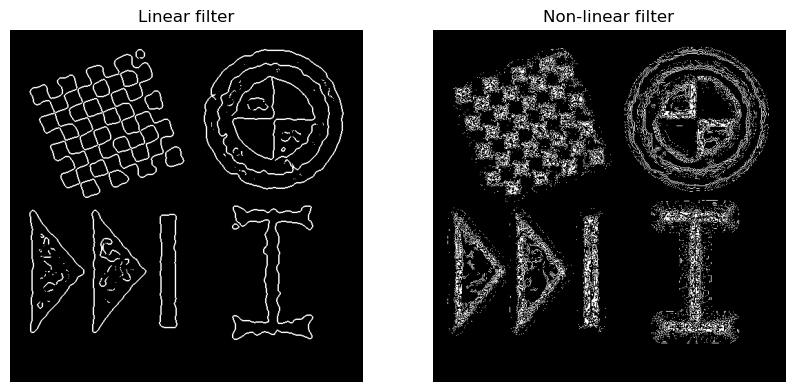

In [23]:
THETA_EDGE = 0.1

gradient = np.gradient(image0_blur)
gradient_norm = np.sqrt(gradient[0]**2 + gradient[1]**2)
image0_edges1 = (image0_Y1==1) & (gradient_norm>THETA_EDGE*np.max(gradient_norm))
image0_edges2 = (image0_L2==1) & (gradient_norm>THETA_EDGE*np.max(gradient_norm))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Linear filter")
plt.imshow(image0_edges1, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Non-linear filter")
plt.imshow(image0_edges2, cmap='gray')
plt.axis('off')

plt.show()

Compose all previous steps into a single function

In [24]:
def EdgeDetect(image, sigma, theta_edge, linear=True):
    ksize = int(np.ceil(3*sigma))*2 + 1 
    
    # define Gaussian kernel
    kernel_1d = cv2.getGaussianKernel(ksize, sigma)
    G = kernel_1d @ kernel_1d.T

    # create Gaussian blurred image
    image_blur = cv2.filter2D(image, -1, G)

    # define morphological filters kernel
    B = np.array([[0, 1, 0],
                  [1, 1, 1],
                  [0, 1, 0]], dtype=np.uint8)

    if linear:
        # define LoG kernel
        x, y = np.meshgrid(np.arange(-ksize//2, ksize//2 + 1), np.arange(-ksize//2, ksize//2 + 1))
        norm2 = x**2 + y**2
        LoG = -(1.0 / (np.pi * sigma**4)) * (1 - norm2 / (2.0 * sigma**2)) * np.exp(-norm2 / (2.0 * sigma**2))
        LoG -= LoG.mean()

        # convolve image with LoG
        image_L1 = cv2.filter2D(image, cv2.CV_64F, LoG)

        # Binary sign image
        image_X1 = (image_L1 >= 0).astype(np.uint8)

        # Find border
        image_Y1 = cv2.dilate(image_X1, B) - cv2.erode(image_X1, B)
   
        D = image_Y1

    else:
        # apply morphological filters
        image_L2 = cv2.dilate(image_blur, B) + cv2.erode(image_blur, B) - 2*image_blur

        D = image_L2

    # define norm of gradient of blurred image
    gradient = np.gradient(image_blur)
    gradient_norm = np.sqrt(gradient[0]**2 + gradient[1]**2)

    # keep only steep edges
    D = (D == 1) & (gradient_norm > theta_edge*np.max(gradient_norm))

    return D

## 1.3 Αξιολόγηση των Αποτελεσμάτων Ανίχνευσης Ακμών

locate real edges

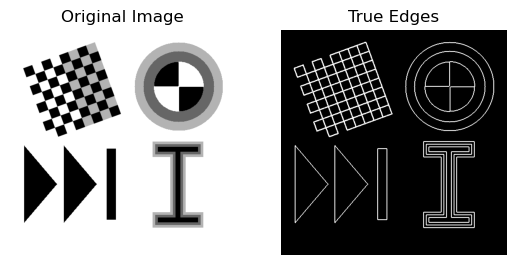

In [25]:
THETA_REALEDGE = 1

# perform edge operator
M = cv2.dilate(image0, B) - cv2.erode(image0, B)

# binary image
T = M > THETA_REALEDGE

# show result
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image0, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("True Edges")
plt.imshow(T, cmap='gray')
plt.axis('off')

plt.show()

define function that reviews the edge detection quality

In [26]:
def score(detected_edges, true_edges):
    D = detected_edges
    T = true_edges
    precision = ((D==1) & (T==1)).sum()/D.sum()
    recall = ((D==1) & (T==1)).sum()/T.sum()
    return (precision + recall)/2

# test function
print(score(T,T))
print(score(image0_edges1, T))
print(score(image0_edges2, T))


1.0
0.5224077452827323
0.20283989952152065


experiment with different parameters

<function matplotlib.pyplot.show(close=None, block=None)>

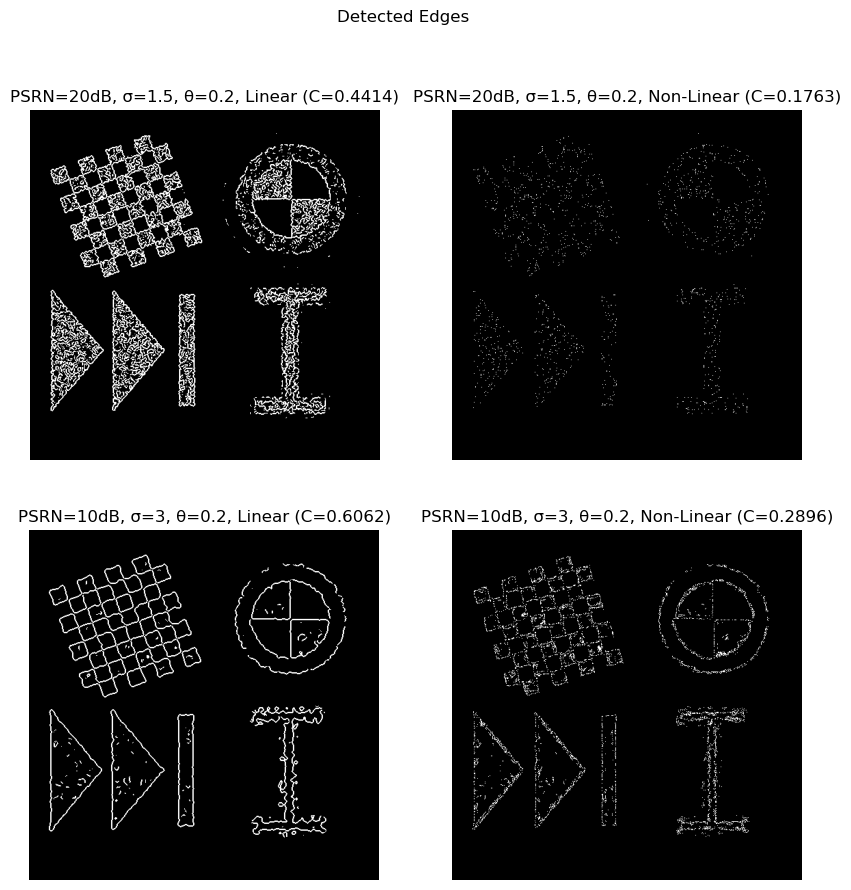

In [27]:
# PSRN==20
linear_20 = EdgeDetect(image0_20, 1.5, 0.2, True)
non_linear_20 = EdgeDetect(image0_20, 1.5, 0.2, False)

# PSRN==10
linear_10 = EdgeDetect(image0_10, 3, 0.2, True)
non_linear_10 = EdgeDetect(image0_10, 3, 0.2, False)

# Show results
plt.figure(figsize=(10,10))

plt.subplot(2,2,1)
plt.suptitle("Detected Edges")
plt.title(f"PSRN=20dB, σ=1.5, θ=0.2, Linear (C={score(linear_20, T):.4f})")
plt.imshow(linear_20, cmap='gray')
plt.axis('off')

plt.subplot(2,2,2)
plt.title(f"PSRN=20dB, σ=1.5, θ=0.2, Non-Linear (C={score(non_linear_20, T):.4f})")
plt.imshow(non_linear_20, cmap='gray')
plt.axis('off')

plt.subplot(2,2,3)
plt.title(f"PSRN=10dB, σ=3, θ=0.2, Linear (C={score(linear_10, T):.4f})")
plt.imshow(linear_10, cmap='gray')
plt.axis('off')

plt.subplot(2,2,4)
plt.title(f"PSRN=10dB, σ=3, θ=0.2, Non-Linear (C={score(non_linear_10, T):.4f})")
plt.imshow(non_linear_10, cmap='gray')
plt.axis('off')

plt.show

tweak parameters

<function matplotlib.pyplot.show(close=None, block=None)>

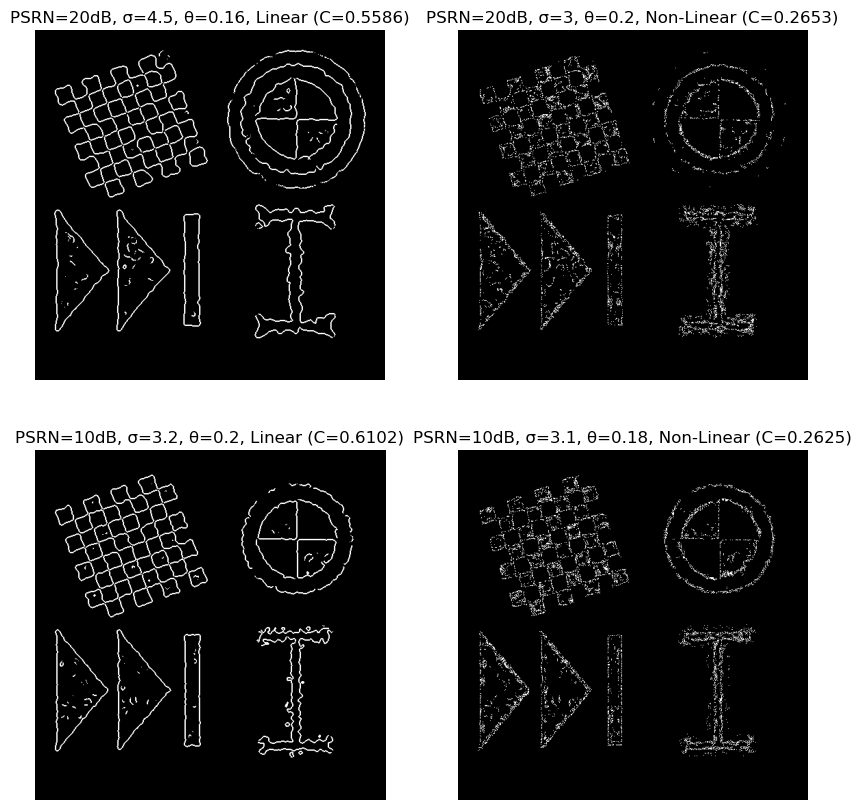

In [28]:
# tweak parameters
linear_20_sigma = 4.5
linear_20_theta = 0.16

non_linear_20_sigma = 3
non_linear_20_theta = 0.2

linear_10_sigma = 3.2
linear_10_theta = 0.2

non_linear_10_sigma = 3.1
non_linear_10_theta = 0.18

# PSRN==20
linear_20 = EdgeDetect(image0_20, linear_20_sigma, linear_20_theta, True)
non_linear_20 = EdgeDetect(image0_20, non_linear_20_sigma, non_linear_20_theta, False)

# PSRN==10
linear_10 = EdgeDetect(image0_10, linear_10_sigma, linear_10_theta, True)
non_linear_10 = EdgeDetect(image0_10, non_linear_10_sigma, non_linear_10_theta, False)

# Show results
plt.figure(figsize=(10,10))

plt.subplot(2,2,1)
plt.title(f"PSRN=20dB, σ={linear_20_sigma}, θ={linear_20_theta}, Linear (C={score(linear_20, T):.4f})")
plt.imshow(linear_20, cmap='gray')
plt.axis('off')

plt.subplot(2,2,2)
plt.title(f"PSRN=20dB, σ={non_linear_20_sigma}, θ={non_linear_20_theta}, Non-Linear (C={score(non_linear_20, T):.4f})")
plt.imshow(non_linear_20, cmap='gray')
plt.axis('off')

plt.subplot(2,2,3)
plt.title(f"PSRN=10dB, σ={linear_10_sigma}, θ={linear_10_theta}, Linear (C={score(linear_10, T):.4f})")
plt.imshow(linear_10, cmap='gray')
plt.axis('off')

plt.subplot(2,2,4)
plt.title(f"PSRN=10dB, σ={non_linear_10_sigma}, θ={non_linear_10_theta}, Non-Linear (C={score(non_linear_10, T):.4f})")
plt.imshow(non_linear_10, cmap='gray')
plt.axis('off')

plt.show

## 1.4 Εφαρμογή των Αλγορίθμων Ανίχνευσης Ακμών σε Πραγματικές Εικόνες

load image and perform EdgeDetect()

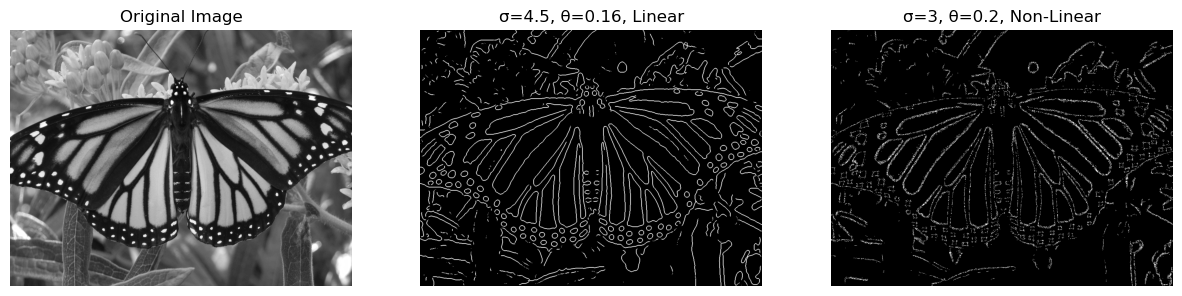

In [29]:
# Load butterfly image
image1 = cv2.imread('butterfly.jpg')

# Convert the image from BGR to GRAY
image1= cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)

# tweak parameters
linear_sigma = 4.5
linear_theta = 0.16

non_linear_sigma = 3
non_linear_theta = 0.2

# Perform Edge Detection
linear = EdgeDetect(image1, linear_sigma, linear_theta, True)
non_linear = EdgeDetect(image1, non_linear_sigma, non_linear_theta, False)

# Show Results
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(image1, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title(f"σ={linear_sigma}, θ={linear_theta}, Linear")
plt.imshow(linear, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title(f"σ={non_linear_sigma}, θ={non_linear_theta}, Non-Linear")
plt.imshow(non_linear, cmap='gray')
plt.axis('off')

plt.show()

see how parameters affect result

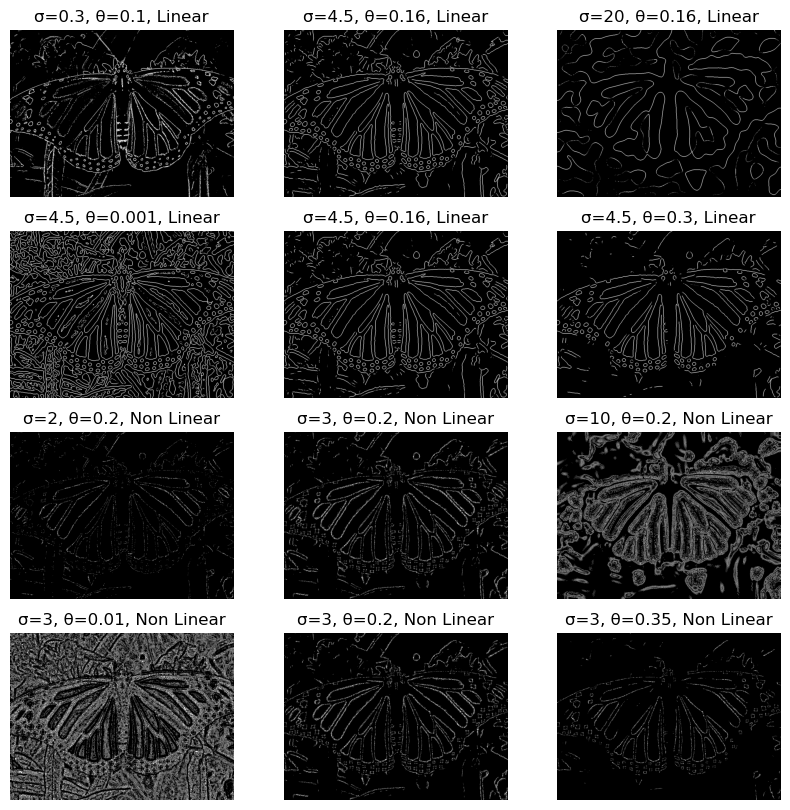

In [30]:
# Load butterfly image
image1 = cv2.imread('butterfly.jpg')

# Convert the image from BGR to GRAY
image1= cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)

# tweak parameters
linear_sigma = [[0.3, 4.5, 20],
                [4.5, 4.5, 4.5]]
linear_theta = [[0.1, 0.16, 0.16],
                [0.001, 0.16, 0.3]]
non_linear_sigma = [[2, 3, 10],
                    [3, 3, 3]]
non_linear_theta = [[0.2, 0.2, 0.2],
                    [0.01, 0.2, 0.35]]

# Perform Edge Detection
linear=[]
non_linear=[]
for i in range(2):
    for j in range(3):
        linear.append(EdgeDetect(image1, linear_sigma[i][j], linear_theta[i][j], True))
        non_linear.append(EdgeDetect(image1, non_linear_sigma[i][j], non_linear_theta[i][j], False))

# Show Results
plt.figure(figsize=(10,10))

for i in range(6):
    plt.subplot(4,3,i+1)
    plt.title(f"σ={linear_sigma[i//3][i%3]}, θ={linear_theta[i//3][i%3]}, Linear")
    plt.imshow(linear[i], cmap='gray')
    plt.axis('off')

for i in range(6):
    plt.subplot(4,3,i+7)
    plt.title(f"σ={non_linear_sigma[i//3][i%3]}, θ={non_linear_theta[i//3][i%3]}, Non Linear")
    plt.imshow(non_linear[i], cmap='gray')
    plt.axis('off')

plt.show()